# Deep Learning para Visión por Computador
Este notebook introduce las redes neuronales convolucionales (CNN) y muestra cómo entrenar una red simple con Keras sobre el dataset MNIST.

In [1]:
# Librerías necesarias
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

## Carga del dataset MNIST
Este conjunto contiene imágenes de dígitos escritos a mano (0 al 9).

In [ ]:
# Cargar y preparar datos
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalizar a [0,1]
x_train, x_test = x_train / 255.0, x_test / 255.0

# Añadir dimensión de canal
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

print("Tamaño del set de entrenamiento:", x_train.shape)
print("Tamaño del set de prueba:", x_test.shape)

Tamaño del set de entrenamiento: (60000, 28, 28, 1)
Tamaño del set de prueba: (10000, 28, 28, 1)


## Visualización de algunas imágenes

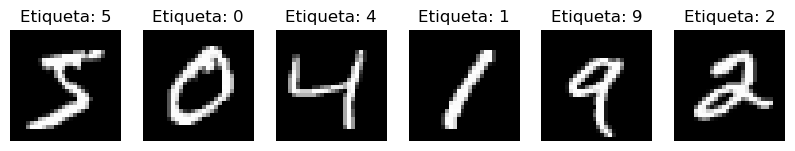

In [3]:
# Mostrar primeros 6 dígitos
plt.figure(figsize=(10, 2))
for i in range(6):
    plt.subplot(1, 6, i+1)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.title(f"Etiqueta: {y_train[i]}")
    plt.axis('off')
plt.show()

## Construcción de una CNN simple

In [4]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/home/jmsa/miniforge3/envs/pia-ud1/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

## Entrenamiento del modelo

In [5]:
history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

Epoch 1/5


2026-03-09 17:04:50.161426: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 188160000 exceeds 10% of free system memory.


1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9048 - loss: 0.3118

2026-03-09 17:05:54.370216: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 31360000 exceeds 10% of free system memory.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 35ms/step - accuracy: 0.9573 - loss: 0.1417 - val_accuracy: 0.9832 - val_loss: 0.0540
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 32ms/step - accuracy: 0.9859 - loss: 0.0471 - val_accuracy: 0.9855 - val_loss: 0.0438
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 76s 29ms/step - accuracy: 0.9902 - loss: 0.0314 - val_accuracy: 0.9891 - val_loss: 0.0339
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 32ms/step - accuracy: 0.9912 - loss: 0.0252 - val_accuracy: 0.9906 - val_loss: 0.0281
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 46s 24ms/step - accuracy: 0.9946 - loss: 0.0173 - val_accuracy: 0.9908 - val_loss: 0.0303


## Evaluación y predicciones

In [6]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Precisión en el set de prueba:", test_acc)

 11/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9914 - loss: 0.0226

2026-03-09 17:14:56.640007: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 31360000 exceeds 10% of free system memory.


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9908 - loss: 0.0303
Precisión en el set de prueba: 0.9908000230789185


## Actividad guiada

In [7]:
from IPython.display import Markdown
Markdown('''
**Actividad:**

1. Cambia la arquitectura de la red (número de capas o filtros).
2. Prueba con un número diferente de épocas.
3. Compara resultados de entrenamiento y validación.
4. Reflexiona: ¿qué ventajas tiene usar CNN frente a métodos clásicos?
''')


**Actividad:**

1. Cambia la arquitectura de la red (número de capas o filtros).
2. Prueba con un número diferente de épocas.
3. Compara resultados de entrenamiento y validación.
4. Reflexiona: ¿qué ventajas tiene usar CNN frente a métodos clásicos?
